# Sobrevivência no Titanic — Classificação Binária

**Objetivo:** prever se um passageiro sobreviveu ao naufrágio a partir de dados cadastrais
(classe, sexo, idade, tarifa, família a bordo) — o "hello world" clássico de classificação
binária. Ao lado do projeto de risco de crédito, forma a dupla de classificação binária deste
portfólio, dessa vez comparando 4 algoritmos diferentes lado a lado.

**Nota:** a análise (EDA, tratamento, engenharia de variáveis e os 4 modelos) é autoral — feita
em dois notebooks separados. Aqui eles estão juntos em um só, organizados na mesma estrutura do
resto do portfólio, com a conclusão consolidada ao final.

## 1. Importação e carregamento dos dados

Ajuste técnico em relação ao notebook original: carrego direto do `titanic_data.csv` (já
exportado) em vez de `sns.load_dataset('titanic')` — evita dependência de internet e deixa o
notebook reproduzível offline, no mesmo padrão dos outros projetos do portfólio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = pd.read_csv('titanic_data.csv')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Visão geral do dataset

In [2]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [3]:
null_values = titanic.isnull().sum().sort_values(ascending=False)
print(null_values)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64


In [4]:
titanic.nunique().sort_values(ascending=False)

fare           248
age             88
sibsp            7
parch            7
deck             7
pclass           3
embarked         3
class            3
who              3
embark_town      3
survived         2
sex              2
adult_male       2
alive            2
alone            2
dtype: int64

## 3. Análise exploratória inicial

Text(38.99532214506172, 0.5, 'Count of Passengers')

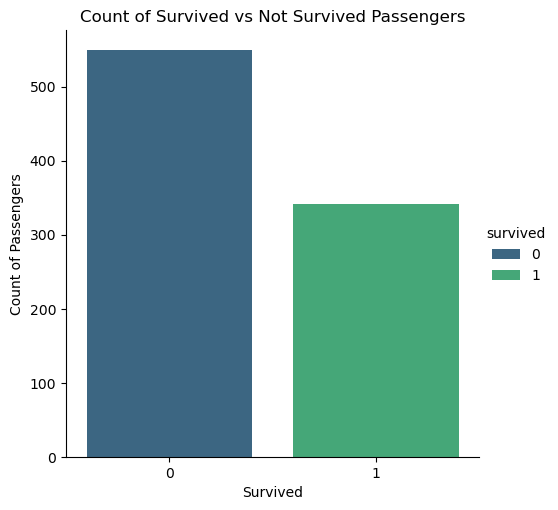

In [5]:
sns.catplot(data=titanic, x="survived", kind="count", hue="survived", palette="viridis")
plt.title('Count of Survived vs Not Survived Passengers')
plt.xlabel('Survived')
plt.ylabel('Count of Passengers')

Text(36.536375, 0.5, 'Count of Passengers')

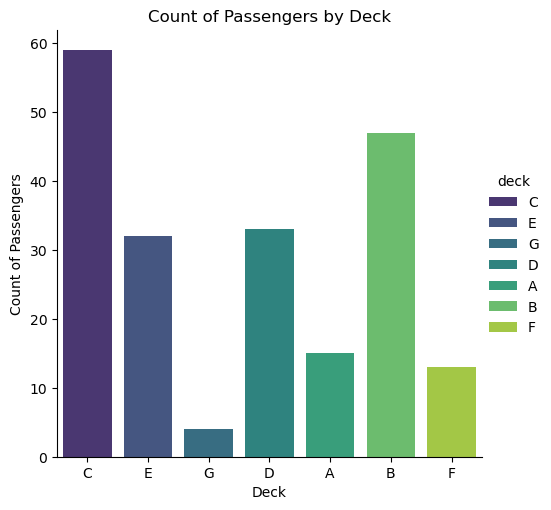

In [6]:
sns.catplot(data=titanic, x="deck", kind="count", hue="deck", palette="viridis")
plt.title('Count of Passengers by Deck')
plt.xlabel('Deck')
plt.ylabel('Count of Passengers')

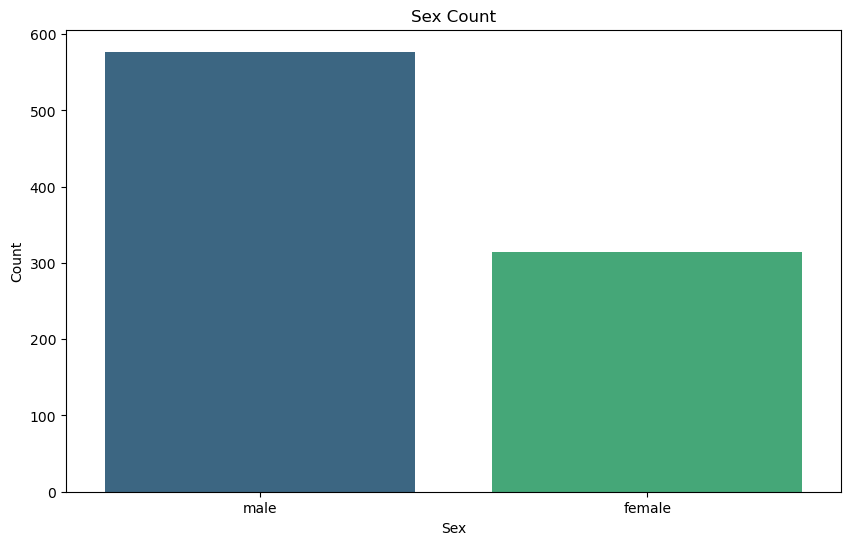

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic, x='sex', hue='sex', palette='viridis', legend=False)
plt.title('Sex Count')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

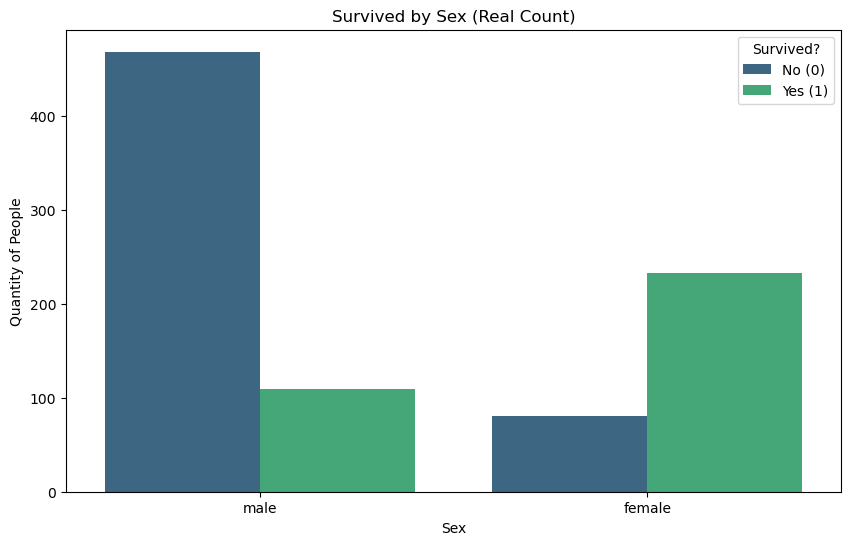

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic, x='sex', hue='survived', palette='viridis')
plt.title('Survived by Sex (Real Count)')
plt.xlabel('Sex')
plt.ylabel('Quantity of People')
plt.legend(title='Survived?', labels=['No (0)', 'Yes (1)'])
plt.show()

In [9]:
min_age = titanic['age'].min()
max_age = titanic['age'].max()
average_age = titanic['age'].mean()
print(f'Minimum age: {min_age}\nMaximum age: {max_age}\nAverage age: {average_age:.2f}')

Minimum age: 0.42
Maximum age: 80.0
Average age: 29.70


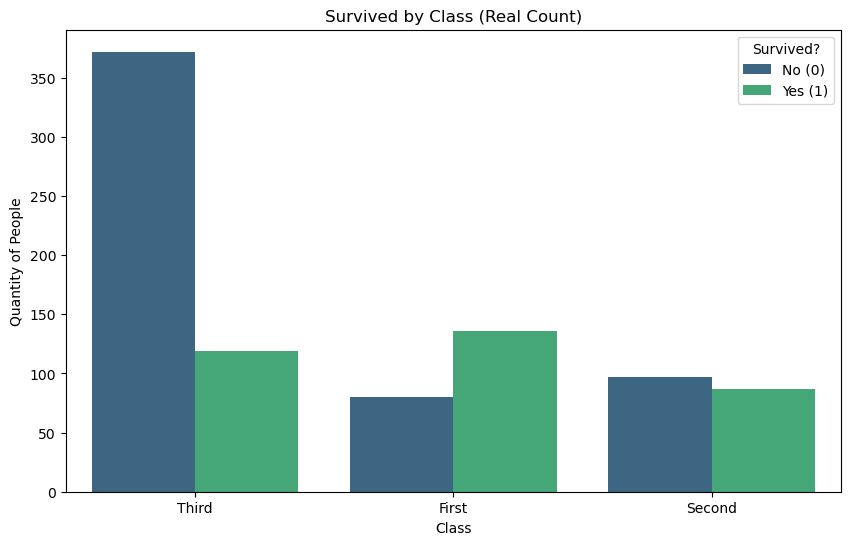

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic, x='class', hue='survived', palette='viridis')
plt.title('Survived by Class (Real Count)')
plt.xlabel('Class')
plt.ylabel('Quantity of People')
plt.legend(title='Survived?', labels=['No (0)', 'Yes (1)'])
plt.show()

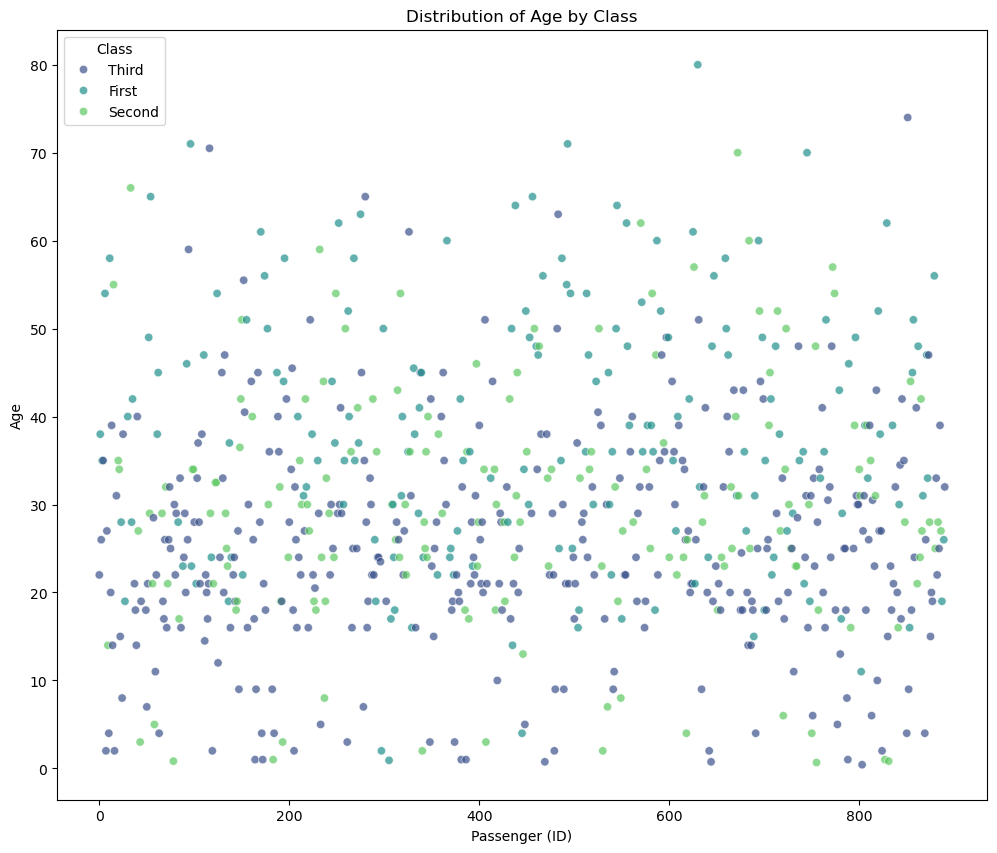

In [11]:
plt.figure(figsize=(12, 10))
sns.scatterplot(data=titanic.reset_index(), x='index', y='age', hue='class', palette='viridis', alpha=0.7)
plt.title('Distribution of Age by Class')
plt.xlabel('Passenger (ID)')
plt.ylabel('Age')
plt.legend(title='Class')
plt.show()

## 4. Limpeza e tratamento de dados

`age` e `embarked` têm nulos — cada um tratado de um jeito diferente, dependendo do tipo de
variável.

In [12]:
mode_embarked = titanic['embarked'].mode()[0]
titanic['embarked'] = titanic['embarked'].fillna(mode_embarked)

`embarked` é categórica qualitativa — faz sentido usar a moda pra preencher os nulos.

In [13]:
mean_age_class = titanic.groupby('pclass', observed=False)['age'].mean().reset_index()
print(mean_age_class)

   pclass        age
0       1  38.233441
1       2  29.877630
2       3  25.140620


In [14]:
titanic['age'] = titanic.apply(lambda row: mean_age_class.loc[mean_age_class['pclass'] == row['pclass'], 'age'].values[0]
                          if pd.isnull(row['age']) else row['age'], axis=1)

`age` é quantitativa — em vez da média geral, uso a média de idade **por classe**, que é mais
informativa (passageiros de 1ª classe tendiam a ser mais velhos que os de 3ª).

In [15]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

`deck` continua com 688 nulos (77% da base) — não vale a pena imputar uma variável com tanta
ausência; ela simplesmente não entra no dataset final.

## 5. Engenharia de variáveis

Transformando `age` e `fare` (contínuas) em faixas categóricas, e criando uma variável de
tamanho de família a partir de `sibsp` (irmãos/cônjuge) + `parch` (pais/filhos).

In [16]:
age_bins = [0, 12, 18, 35, 60, np.inf]
age_labels = ['0-12', '13-18', '19-35', '36-60', '60+']
titanic['age_group'] = pd.cut(titanic['age'], bins=age_bins, labels=age_labels)

fare_bins = [0, 7.91, 14.454, 31, np.inf]
fare_labels = ['0-7.91', '7.91-14.454', '14.454-31', '31+']
titanic['fare_group'] = pd.cut(titanic['fare'], bins=fare_bins, labels=fare_labels)

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,fare_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,19-35,0-7.91
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,36-60,31+
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,19-35,7.91-14.454
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,19-35,31+
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,19-35,7.91-14.454


Tamanho de família: `alone` (viajando sozinho), `small` (2-4 pessoas), `big` (5+ pessoas).

In [17]:
# Adding 1 for the passenger themselves
titanic['familysize_num'] = titanic['sibsp'] + titanic['parch'] + 1

# Bins: 0-1 (Alone), 1-4 (Small), 4-20 (Big)
bins = [0, 1, 4, 20]
labels = ['alone', 'small', 'big']
titanic['familysize'] = pd.cut(titanic['familysize_num'], bins=bins, labels=labels)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,fare_group,familysize_num,familysize
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,19-35,0-7.91,2,small
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,36-60,31+,2,small
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,19-35,7.91-14.454,1,alone
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,19-35,31+,2,small
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,19-35,7.91-14.454,1,alone


Taxa de sobrevivência por cada variável categórica — um primeiro raio-x de quais features
parecem importar antes de rodar qualquer modelo.

In [18]:
for column in ['pclass', 'sex','who', 'embarked', 'age_group', 'fare_group', 'familysize']:
    survival = titanic.groupby(column, observed=False)['survived'].mean().reset_index()
    print(f'Survival by {column}:\n{survival}\n')

Survival by pclass:
   pclass  survived
0       1  0.629630
1       2  0.472826
2       3  0.242363

Survival by sex:
      sex  survived
0  female  0.742038
1    male  0.188908

Survival by who:
     who  survived
0  child  0.590361
1    man  0.163873
2  woman  0.756458

Survival by embarked:
  embarked  survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009

Survival by age_group:
  age_group  survived
0      0-12  0.579710
1     13-18  0.428571
2     19-35  0.346535
3     36-60  0.408889
4       60+  0.227273

Survival by fare_group:
    fare_group  survived
0       0-7.91  0.206731
1  7.91-14.454  0.308756
2    14.454-31  0.445415
3          31+  0.581081

Survival by familysize:
  familysize  survived
0      alone  0.303538
1      small  0.578767
2        big  0.161290



## 6. Dataset final

Seleciono só as colunas tratadas/derivadas pra modelagem (nada de `age`/`fare` crus, já que
viraram `age_group`/`fare_group`) e salvo — esse é o arquivo que a seção de modelagem usa.

In [19]:
final_titanic = titanic[['survived','pclass', 'who', 'embarked', 'age_group', 'fare_group', 'familysize']]
final_titanic.to_csv('titanic_final.csv', index=False)
final_titanic.head()

,survived,pclass,who,embarked,age_group,fare_group,familysize
0,0,3,man,S,19-35,0-7.91,small
1,1,1,woman,C,36-60,31+,small
2,1,3,woman,S,19-35,7.91-14.454,alone
3,1,1,woman,S,19-35,31+,small
4,0,3,man,S,19-35,7.91-14.454,alone


## 7. Visualizações do dataset processado

### Sobrevivência por classe
A maioria dos sobreviventes tinha mais dinheiro (1ª classe).

   pclass  survived
0       1       216
1       2       184
2       3       491


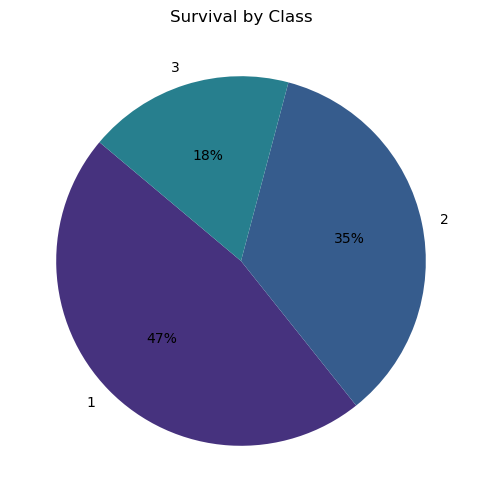

In [20]:
table_by_class = final_titanic.groupby('pclass', observed=False)['survived'].count().reset_index()
print(table_by_class)
survival_by_class = final_titanic.groupby('pclass', observed=False)['survived'].mean().reset_index()
color = sns.color_palette('viridis')[0:4]
plt.figure(figsize=(8, 6))
plt.pie(survival_by_class['survived'], labels=survival_by_class['pclass'], colors=color, autopct='%.0f%%', startangle=140)
plt.title('Survival by Class')
plt.show()

### Sobrevivência por categoria (who)
A maioria dos sobreviventes eram mulheres.

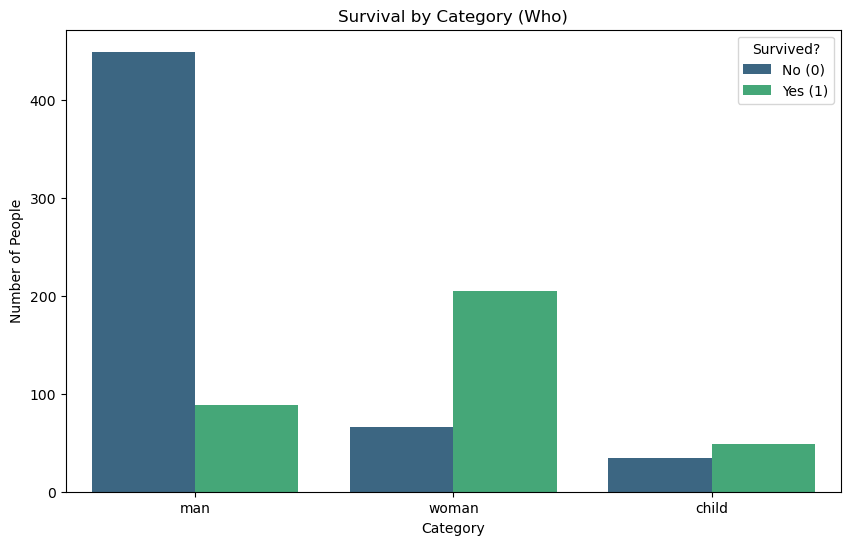

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(data=final_titanic, x='who', hue='survived', palette='viridis')
plt.title('Survival by Category (Who)')
plt.xlabel('Category')
plt.ylabel('Number of People')
plt.legend(title='Survived?', labels=['No (0)', 'Yes (1)'])
plt.show()

### Sobrevivência por porto de embarque, faixa etária e faixa de tarifa

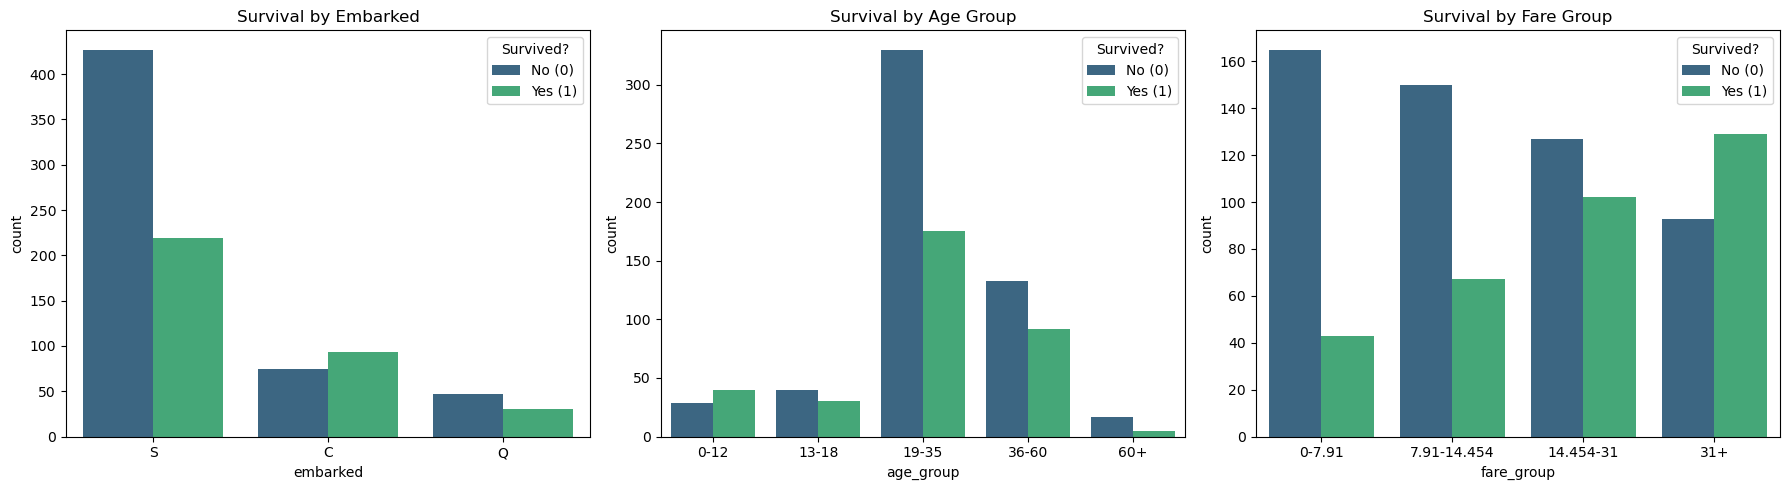

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=final_titanic, x='embarked', hue='survived', palette='viridis', ax=axes[0])
axes[0].set_title('Survival by Embarked')
axes[0].legend(title='Survived?', labels=['No (0)', 'Yes (1)'])

sns.countplot(data=final_titanic, x='age_group', hue='survived', palette='viridis', ax=axes[1])
axes[1].set_title('Survival by Age Group')
axes[1].legend(title='Survived?', labels=['No (0)', 'Yes (1)'])

sns.countplot(data=final_titanic, x='fare_group', hue='survived', palette='viridis', ax=axes[2])
axes[2].set_title('Survival by Fare Group')
axes[2].legend(title='Survived?', labels=['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

## 8. Modelagem: comparando 4 algoritmos de classificação

Cada função treina um algoritmo diferente no mesmo `titanic_final.csv` (one-hot encoding das
categóricas, split 75/25, `random_state=42` fixo em todas pra comparação justa) e retorna a
acurácia — Árvore de Decisão, Regressão Logística, SVM e KNN.

In [23]:
# Geral Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# SVM
from sklearn.svm import SVC

# KNN
from sklearn.neighbors import KNeighborsClassifier

In [24]:
def Decision_Tree():
    df = pd.read_csv('titanic_final.csv')
    target = 'survived'
    X = pd.get_dummies(df.drop(target, axis=1), drop_first=True)
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    prev = model.predict(X_test)
    accuracy = accuracy_score(y_test, prev)
    print(f"\n✅ DECISION TREE ACCURACY: {accuracy:.2%}")
    print(confusion_matrix(y_test, prev))
    return accuracy

In [25]:
def Logistic_Regression():
    df = pd.read_csv('titanic_final.csv')
    target = 'survived'
    X = pd.get_dummies(df.drop(target, axis=1), drop_first=True)
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    prev = model.predict(X_test)
    accuracy = accuracy_score(y_test, prev)
    print(f"\n✅ LOGISTIC REGRESSION ACCURACY: {accuracy:.2%}")
    print(confusion_matrix(y_test, prev))
    return accuracy

In [26]:
def SVM():
    df = pd.read_csv('titanic_final.csv')
    target = 'survived'
    X = pd.get_dummies(df.drop(target, axis=1), drop_first=True)
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model = SVC(kernel='rbf', random_state=42)
    model.fit(X_train, y_train)
    prev = model.predict(X_test)
    accuracy = accuracy_score(y_test, prev)
    print(f"\n✅ SVM ACCURACY: {accuracy:.2%}")
    print(confusion_matrix(y_test, prev))
    return accuracy

In [27]:
def KNN():
    df = pd.read_csv('titanic_final.csv')
    target = 'survived'
    X = pd.get_dummies(df.drop(target, axis=1), drop_first=True)
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train, y_train)
    prev = model.predict(X_test)
    accuracy = accuracy_score(y_test, prev)
    print(f"\n✅ KNN ACCURACY: {accuracy:.2%}")
    print(confusion_matrix(y_test, prev))
    return accuracy

In [28]:
# Compare the models
def compare_models():
    dt_accuracy = Decision_Tree()
    lr_accuracy = Logistic_Regression()
    svm_accuracy = SVM()
    knn_accuracy = KNN()
    print("\n📊 COMPARAÇÃO DE MODELOS:")
    print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")
    print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")
    print(f"SVM Accuracy: {svm_accuracy:.2%}")
    print(f"KNN Accuracy: {knn_accuracy:.2%}")

compare_models()


✅ DECISION TREE ACCURACY: 82.51%
[[119  15]
 [ 24  65]]

✅ LOGISTIC REGRESSION ACCURACY: 82.51%
[[116  18]
 [ 21  68]]

✅ SVM ACCURACY: 82.51%
[[119  15]
 [ 24  65]]

✅ KNN ACCURACY: 83.41%
[[112  22]
 [ 15  74]]

📊 COMPARAÇÃO DE MODELOS:
Decision Tree Accuracy: 82.51%
Logistic Regression Accuracy: 82.51%
SVM Accuracy: 82.51%
KNN Accuracy: 83.41%


## 9. Indo além da acurácia: precisão e recall por modelo

As 4 funções acima só retornam acurácia. Reaproveitando a mesma matriz de confusão que cada uma
já imprime (mesmo split, `random_state=42` fixo), calculo precisão e recall pra cada modelo —
o mesmo raciocínio do post do blog sobre [precisão x recall](../blog/precisao-recall-f1-acuracia.html):
dois modelos podem empatar em acurácia e ainda assim errar de formas diferentes.

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

def treinar_e_avaliar(modelo, nome):
    df = pd.read_csv('titanic_final.csv')
    X = pd.get_dummies(df.drop('survived', axis=1), drop_first=True)
    y = df['survived']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    modelo.fit(X_train, y_train)
    prev = modelo.predict(X_test)
    return {
        'modelo': nome,
        'acuracia': accuracy_score(y_test, prev),
        'precisao': precision_score(y_test, prev),
        'recall': recall_score(y_test, prev),
        'f1': f1_score(y_test, prev),
    }

resultados = pd.DataFrame([
    treinar_e_avaliar(DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42), 'Decision Tree'),
    treinar_e_avaliar(LogisticRegression(max_iter=1000, random_state=42), 'Logistic Regression'),
    treinar_e_avaliar(SVC(kernel='rbf', random_state=42), 'SVM'),
    treinar_e_avaliar(KNeighborsClassifier(n_neighbors=5), 'KNN'),
])
resultados.round(4)

,modelo,acuracia,precisao,recall,f1
0,Decision Tree,0.8251,0.8125,0.7303,0.7692
1,Logistic Regression,0.8251,0.7907,0.7640,0.7771
2,SVM,0.8251,0.8125,0.7303,0.7692
3,KNN,0.8341,0.7708,0.8315,0.8000


## 10. Conclusões

**O que mais determinou sobrevivência (seção 5):** a variável mais forte, disparada, foi **sexo**
— mulheres sobreviveram 74,2% das vezes contra 18,9% dos homens, uma diferença de 55 pontos
percentuais. Crianças também se destacam (59,0%). Classe social tem um gradiente claro e
monotônico (1ª: 63,0% → 2ª: 47,3% → 3ª: 24,2%), assim como a faixa de tarifa (quanto mais caro o
bilhete, maior a sobrevivência: 20,7% → 58,1%) — o que faz sentido, já que tarifa e classe estão
correlacionadas.

**Achado menos óbvio:** tamanho de família **não é monotônico** — viajar `small` (2 a 4 pessoas)
teve a *maior* sobrevivência (57,9%), maior até que viajar sozinho (30,4%), e viajar em família
`big` (5+) teve a *menor* de todas (16,1%). Faz sentido em retrospecto (família pequena ajuda a
se organizar no resgate; família grande atrasa todo mundo; sozinho não tem ninguém puxando),
mas não é um padrão que um modelo linear simples capturaria bem sem essa categorização explícita
em faixas — é exatamente o tipo de não-linearidade que justifica fazer feature engineering em
vez de jogar `sibsp`/`parch` crus no modelo.

**Comparação dos 4 modelos (seção 8-9):**

| Modelo | Acurácia | Precisão | Recall | F1 |
|---|---|---|---|---|
| Decision Tree | 82,51% | 0,8125 | 0,7303 | 0,7692 |
| Logistic Regression | 82,51% | 0,7907 | 0,7640 | 0,7771 |
| SVM | 82,51% | 0,8125 | 0,7303 | 0,7692 |
| KNN | **83,41%** | 0,7708 | **0,8315** | **0,8000** |

**Achado honesto #1:** os 4 modelos ficam espremidos numa faixa de **menos de 1 ponto percentual**
de acurácia (82,51% a 83,41%). Isso não é coincidência de algoritmo bom — é o resultado de já ter
reduzido o dataset a 6 variáveis categóricas bem escolhidas (seção 5-6). Depois de um bom trabalho
de feature engineering, a escolha do algoritmo passa a importar menos do que a escolha das
variáveis — o teto de sinal disponível já foi definido antes de qualquer modelo ser treinado.

**Achado honesto #2:** Decision Tree e SVM produziram matrizes de confusão **idênticas**
(`[[119,15],[24,65]]`). Não é bug — com só 6 variáveis categóricas de baixa cardinalidade, o
espaço de decisão é pequeno o suficiente pra dois algoritmos com fronteiras de decisão diferentes
(árvore vs. hiperplano) convergirem exatamente na mesma partição dos dados.

**Achado honesto #3 (conectando com o post do blog sobre [precisão x recall](../blog/precisao-recall-f1-acuracia.html)):**
KNN venceu em acurácia *e* em recall, mas tem a *menor* precisão do grupo (0,7708) — captura mais
sobreviventes reais (83,2% deles), só que às custas de mais falsos positivos. Se o objetivo fosse
"nunca dizer que alguém sobreviveu quando na verdade não sobreviveu" (precisão), Decision
Tree/SVM empatam na frente; se o objetivo é "não deixar passar nenhum sobrevivente" (recall), KNN
vence com folga. Acurácia sozinha (o que a comparação original media) esconde essa diferença.

**Ressalva de rigor:** essa comparação usa um único split de treino/teste (75/25, `random_state=42`
fixo) — sem validação cruzada. Com 223 passageiros no conjunto de teste, uma diferença de 0,9
ponto percentual entre KNN e os demais está dentro da margem de ruído esperada de um único split;
validação cruzada (k-fold) seria o próximo passo antes de declarar KNN "o melhor modelo" com
confiança estatística.